In [210]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

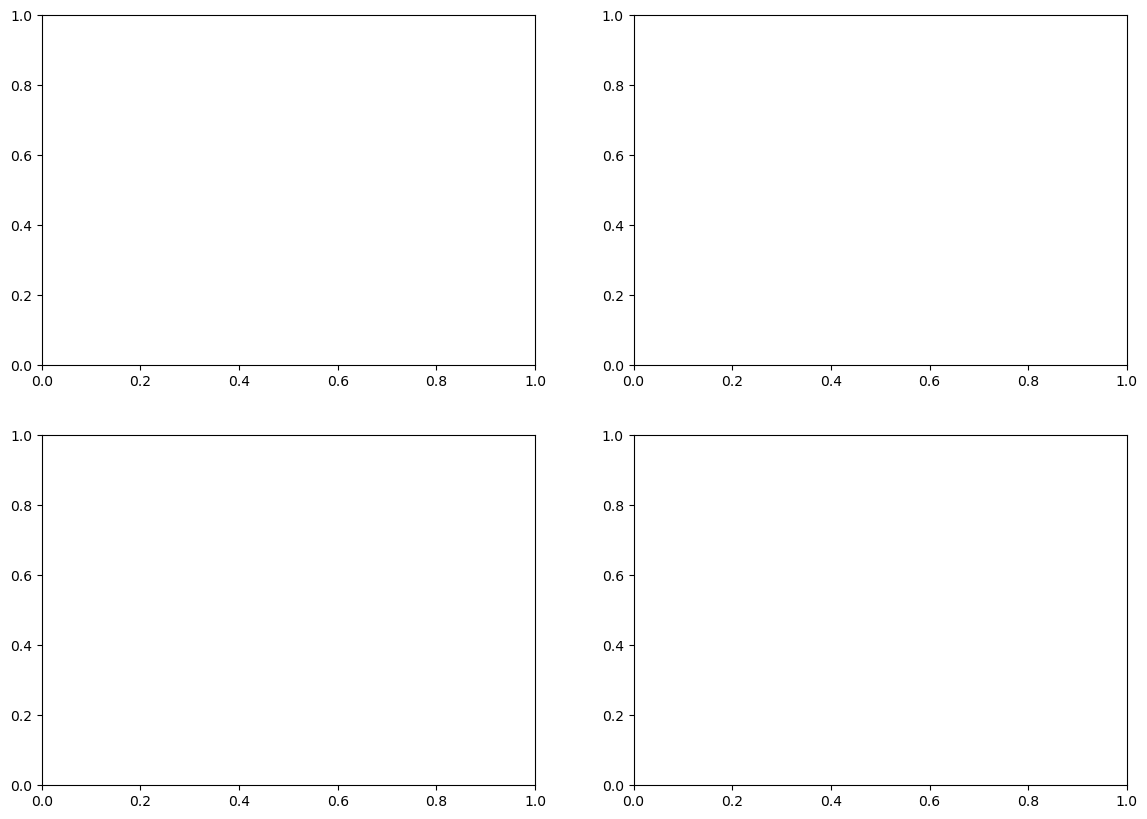

In [451]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

In [ ]:
metadata = pd.read_csv("../data/Multi_classification/metadata.tsv", sep="\t", index_col=0)

### PhyloGCNE

In [473]:
base_path = "../data/Multi_classification/results/"
dfs = [pd.read_csv(f"{base_path}predictions_PhyloGCNE_{i}.csv") for i in range(1, 6)]
predictions = pd.concat(dfs, ignore_index=True)

In [474]:
prob_cols = predictions.filter(like='Prob_Class')
predictions['Predicted_Label'] = prob_cols.idxmax(axis=1)
predictions['Predicted_Class'] = predictions['Predicted_Label'].str.replace('Prob_Class_', '')

In [475]:
y_true = metadata.loc[predictions.SampleID.values, "group"].values.astype(int)
y_pred = predictions.Predicted_Class.values.astype(int)

In [476]:
class_names = ['ASD', 'CRC', 'Control', 'IBD', 'IBS']

In [477]:
cm = confusion_matrix(y_true, y_pred)

In [478]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, 
            yticklabels=class_names,
            square=True,
            cbar_kws={'label': 'Proportion of True Class (Recall)'},
            ax=axes[0, 0])
axes[0,0].set_title("PhyloGCNE")
axes[0,0].set_ylabel('True Label', fontsize=12,)
axes[0,0].set_xlabel('Predicted Label', fontsize=12)

Text(0.5, 517.9040404040405, 'Predicted Label')

In [479]:
macro_f1 = f1_score(y_true, y_pred, average='macro')
macro_f1

0.6615242769926942

### Phylo-Spec

In [ ]:
base_path = "../data/Multi_classification/output/"
dfs = [pd.read_csv(f"{base_path}predictions_{i}.csv") for i in range(1, 6)]
predictions = pd.concat(dfs, ignore_index=True)
prob_cols = predictions.filter(like='Prob_Class')
predictions['Predicted_Label'] = prob_cols.idxmax(axis=1)
predictions['Predicted_Class'] = predictions['Predicted_Label'].str.replace('Prob_Class_', '')

y_true = metadata.loc[predictions.SampleID.values, "group"].values.astype(int)
y_pred = predictions.Predicted_Class.values.astype(int)

cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, 
            yticklabels=class_names,
            square=True,
            cbar_kws={'label': 'Proportion of True Class (Recall)'},
            ax=axes[0, 1])
axes[0, 1].set_title("Phylo_Spec")
axes[0, 1].set_ylabel('True Label', fontsize=12,)
axes[0, 1].set_xlabel('Predicted Label', fontsize=12)

Text(0.5, 500.7222222222223, 'Predicted Label')

### Deepphylo

In [ ]:
base_path = "../GCN/data/Multi_classification/results/"
dfs = [pd.read_csv(f"{base_path}predictions_deepphylo_{i}.csv") for i in range(1, 6)]
predictions = pd.concat(dfs, ignore_index=True)
prob_cols = predictions.filter(like='Prob')
predictions['Predicted_Label'] = prob_cols.idxmax(axis=1)
predictions['Predicted_Class'] = predictions['Predicted_Label'].str.replace('Prob_', '')

y_true = metadata.loc[predictions.SampleID.values, "group"].values.astype(int)
y_pred = predictions.Predicted_Class.values.astype(int)

cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, 
            yticklabels=class_names,
            square=True,
            cbar_kws={'label': 'Proportion of True Class (Recall)'},
            ax=axes[1, 0])
axes[1, 0].set_title("DeepPhylo")
axes[1, 0].set_ylabel('True Label', fontsize=12,)
axes[1, 0].set_xlabel('Predicted Label', fontsize=12)

Text(0.5, 80.7222222222222, 'Predicted Label')

### RF

In [462]:
predictions = pd.read_csv("../data/Multi_classification/results/RF_results.csv")
predictions.columns = ["SampleID", "fold", "Prob_Class_0", "Prob_Class_1", "Prob_Class_2", "Prob_Class_3", "Prob_Class_4"]
prob_cols = predictions.filter(like='Prob')
predictions['Predicted_Label'] = prob_cols.idxmax(axis=1)
predictions['Predicted_Class'] = predictions['Predicted_Label'].str.replace('Prob_Class_', '')

y_true = metadata.loc[predictions.SampleID.values, "group"].values.astype(int)
y_pred = predictions.Predicted_Class.values.astype(int)

cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, 
            yticklabels=class_names,
            square=True,
            cbar_kws={'label': 'Proportion of True Class (Recall)'},
            ax=axes[1, 1])
axes[1, 1].set_title("RF")
axes[1, 1].set_ylabel('True Label', fontsize=12,)
axes[1, 1].set_xlabel('Predicted Label', fontsize=12)

Text(0.5, 80.7222222222222, 'Predicted Label')

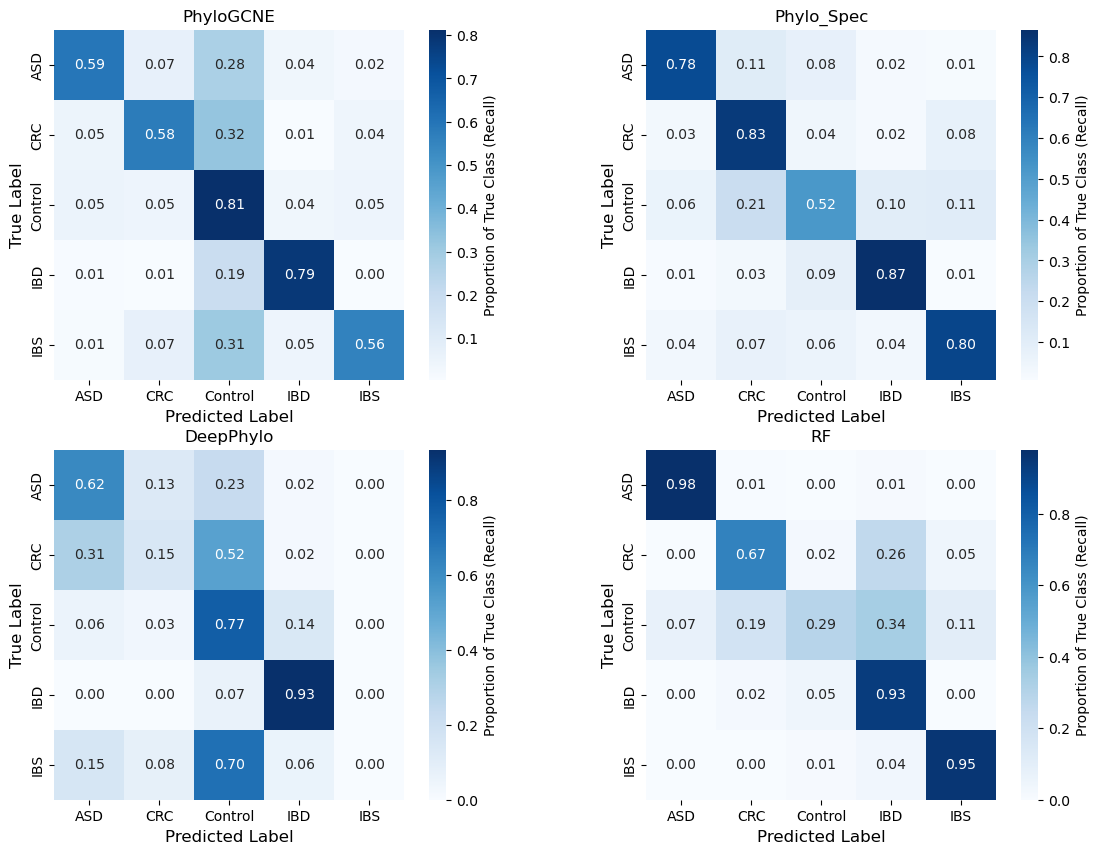

In [463]:
fig

In [464]:
fig.savefig("combined_confusion_matrices.png", dpi=300)

### Macro_f1

In [431]:
### PhyloGCNE
base_path = "../data/Multi_classification/results/"
macro_f1_scores = []

for i in range(1, 6):
    df = pd.read_csv(f"{base_path}predictions_PhyloGCNE_{i}.csv", index_col=0)
    prob_cols = df.filter(like='Prob_Class')
    
    df['Predicted_Label'] = prob_cols.idxmax(axis=1)
    df['Predicted_Class'] = df['Predicted_Label'].str.replace('Prob_Class_', '')

    y_true = metadata.loc[df.index.values, "group"].values.astype(int)
    y_pred = df.Predicted_Class.values.astype(int)

    fold_f1 = f1_score(y_true, y_pred, average='macro')
    macro_f1_scores.append(fold_f1)
    
    print(f"Fold {i} Macro F1: {fold_f1:.4f}")

mean_f1 = np.mean(macro_f1_scores)
std_f1 = np.std(macro_f1_scores)
print("-" * 30)
print(f"Average Macro F1: {mean_f1:.4f} ± {std_f1:.4f}")

Fold 1 Macro F1: 0.6735
Fold 2 Macro F1: 0.6541
Fold 3 Macro F1: 0.6962
Fold 4 Macro F1: 0.6367
Fold 5 Macro F1: 0.6485
------------------------------
Average Macro F1: 0.6618 ± 0.0209


In [432]:
### Phylo-Spec
base_path = "../data/Multi_classification/output/"
macro_f1_scores = []

for i in range(1, 6):
    df = pd.read_csv(f"{base_path}predictions_{i}.csv")
    prob_cols = df.filter(like='Prob_Class')
    df['Predicted_Label'] = prob_cols.idxmax(axis=1)
    df['Predicted_Class'] = df['Predicted_Label'].str.replace('Prob_Class_', '')
    
    y_true = metadata.loc[df.SampleID.values, "group"].values.astype(int)
    y_pred = df.Predicted_Class.values.astype(int)

    fold_f1 = f1_score(y_true, y_pred, average='macro')
    macro_f1_scores.append(fold_f1)
    
    print(f"Fold {i} Macro F1: {fold_f1:.4f}")

mean_f1 = np.mean(macro_f1_scores)
std_f1 = np.std(macro_f1_scores)
print("-" * 30)
print(f"Average Macro F1: {mean_f1:.4f} ± {std_f1:.4f}")

Fold 1 Macro F1: 0.6860
Fold 2 Macro F1: 0.6345
Fold 3 Macro F1: 0.6398
Fold 4 Macro F1: 0.6626
Fold 5 Macro F1: 0.6809
------------------------------
Average Macro F1: 0.6608 ± 0.0209


In [433]:
### Deepphylo
base_path = "../data/Multi_classification/results/"
macro_f1_scores = []

for i in range(1, 6):
    df = pd.read_csv(f"{base_path}predictions_deepphylo_{i}.csv")
    prob_cols = df.filter(like='Prob')
    df['Predicted_Label'] = prob_cols.idxmax(axis=1)
    df['Predicted_Class'] = df['Predicted_Label'].str.replace('Prob_', '')
    
    y_true = metadata.loc[df.SampleID.values, "group"].values.astype(int)
    y_pred = df.Predicted_Class.values.astype(int)

    fold_f1 = f1_score(y_true, y_pred, average='macro')
    macro_f1_scores.append(fold_f1)
    
    print(f"Fold {i} Macro F1: {fold_f1:.4f}")

mean_f1 = np.mean(macro_f1_scores)
std_f1 = np.std(macro_f1_scores)
print("-" * 30)
print(f"Average Macro F1: {mean_f1:.4f} ± {std_f1:.4f}")

Fold 1 Macro F1: 0.4505
Fold 2 Macro F1: 0.4874
Fold 3 Macro F1: 0.4744
Fold 4 Macro F1: 0.4887
Fold 5 Macro F1: 0.4517
------------------------------
Average Macro F1: 0.4705 ± 0.0166


In [434]:
### RF
predictions = pd.read_csv("../data/Multi_classification/results/RF_results.csv")
macro_f1_scores = []

for i in ["fold_1", "fold_2", "fold_3", "fold_4", "fold_5"]:
    df = predictions.loc[predictions.fold == i]
    df.columns = ["SampleID", "fold", "Prob_Class_0", "Prob_Class_1", "Prob_Class_2", "Prob_Class_3", "Prob_Class_4"]
    prob_cols = df.filter(like='Prob')
    df.loc[:, 'Predicted_Label'] = prob_cols.idxmax(axis=1)
    df.loc[:, 'Predicted_Class'] = df['Predicted_Label'].str.replace('Prob_Class_', '')

    y_true = metadata.loc[df.SampleID.values, "group"].values.astype(int)
    y_pred = df.Predicted_Class.values.astype(int)

    fold_f1 = f1_score(y_true, y_pred, average='macro')
    macro_f1_scores.append(fold_f1)
    
    print(f"Fold {i} Macro F1: {fold_f1:.4f}")

mean_f1 = np.mean(macro_f1_scores)
std_f1 = np.std(macro_f1_scores)
print("-" * 30)
print(f"Average Macro F1: {mean_f1:.4f} ± {std_f1:.4f}")

Fold fold_1 Macro F1: 0.6411
Fold fold_2 Macro F1: 0.6551
Fold fold_3 Macro F1: 0.6686
Fold fold_4 Macro F1: 0.6535
Fold fold_5 Macro F1: 0.6165
------------------------------
Average Macro F1: 0.6470 ± 0.0175


/home/dongbiao/tmp/ipykernel_42427/1096021521.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Predicted_Label'] = prob_cols.idxmax(axis=1)
/home/dongbiao/tmp/ipykernel_42427/1096021521.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Predicted_Class'] = df['Predicted_Label'].str.replace('Prob_Class_', '')
/home/dongbiao/tmp/ipykernel_42427/1096021521.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_